In [1]:
import numpy as np
from numpy import dtype
import netCDF4 as nc
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import sklearn
from scipy import stats,signal
from scipy.spatial.distance import cdist
import datetime as dt
from scipy.stats import ttest_ind
from datetime import date
import glob
import csv
import os
from scipy.stats import linregress
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, ListedColormap, TwoSlopeNorm
from scipy.ndimage import gaussian_filter
import datetime
from collections import defaultdict
from scipy.ndimage import gaussian_filter1d

In [35]:
# Open hail files
# open up the hail files
file_extension = '.csv'
os.chdir('/glade/u/home/mgraber/Hail/')

all_filenames = [i for i in glob.glob(f"*{file_extension}")]

df = pd.concat(map(pd.read_csv,['55-59_hail.csv', '60-69_hail.csv', '70-79_hail.csv', '80-89_hail.csv', '90-99_hail.csv', '2000-2004_hail.csv', '2005-2007_hail.csv', '2008_hail.csv', '2009_hail.csv', '2010_hail.csv', '2011_hail.csv', '2012_hail.csv', '2013_hail.csv', '2014_hail.csv', '2015_hail.csv', '2016_hail.csv', '2017_hail.csv', '2018_hail.csv', '2019_hail.csv', '2020_hail.csv', '2021_hail.csv', '2022_hail.csv', '2023_hail.csv', '2024_hail.csv']))

In [36]:
df = df[['yr', 'mo', 'date', 'mag', 'slat', 'slon', 'st', 'loss', 'closs', 'inj']]

In [37]:
# Ensure 'date' is in datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')  # invalid formats become NaT

# Drop rows with invalid or missing dates, if necessary
df = df.dropna(subset=['date'])

# Split the dataframe
# Define thresholds before and after 2010
df_hail_pre2010 = df[(df['date'] < '2010-01-01') & (df['mag'] >= 0.75)].copy()
df_hail_post2010 = df[(df['date'] >= '2010-01-01') & (df['mag'] >= 1.0)].copy()
df_hail = pd.concat([df_hail_pre2010, df_hail_post2010])
df_sig = df[df['mag'] >= 2].copy()
df_3 = df[df['mag'] >= 3].copy()
df_4 = df[df['mag'] >= 4].copy()
df_5 = df[df['mag'] >= 5].copy()

In [38]:
# Extract year from the datetime column
df_hail['year'] = df_hail['date'].dt.year
df_sig['year'] = df_sig['date'].dt.year

# Count unique dates per year
hail_counts = df_hail.groupby('year')['date'].nunique()
sig_counts = df_sig.groupby('year')['date'].nunique()

# Reindex to include all years from 1955 to 2024 (fill missing years with 0)
years = range(1955, 2025)
hail_counts = hail_counts.reindex(years, fill_value=0)
sig_counts = sig_counts.reindex(years, fill_value=0)

In [39]:
hail_counts = np.array(hail_counts)
sig_counts = np.array(sig_counts)

In [7]:
hail_decades = np.array((141.4, 159.1, 179.3, 205.1, 240.4, 231.4, 212.1))
sig_decades = np.array((71, 73.3, 72.8, 89.1, 112.4, 112.6, 120))

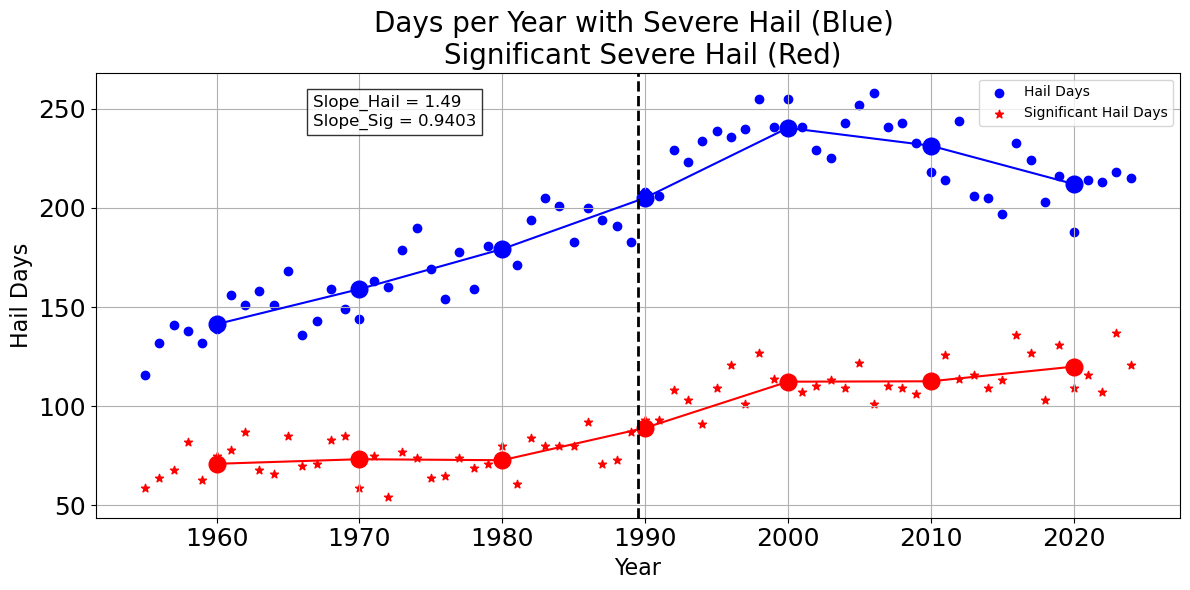

In [8]:
# Plotting
years = np.arange(1955,2024+1,1)
yearss = [1960,1970,1980,1990,2000,2010,2020]
plt.figure(figsize=(12, 6))
plt.scatter(years, hail_counts, label='Hail Days', color='blue')
plt.scatter(years, sig_counts, label='Significant Hail Days', marker='*', color='red')
plt.plot(yearss, hail_decades, color='blue', marker='o',markersize=12)
plt.plot(yearss, sig_decades, color='red', marker='o', markersize=12)
plt.axvline(1989.5, color='black', linestyle='--', linewidth=2)


# Calculate slopes
# Hail
slope_hail, intercept_hail, r_hail, p_hail, stderr_hail = linregress(years, hail_counts)
trend_hail = slope_hail * years + intercept_hail

# Significant Hail
slope_sig, intercept_sig, r_sig, p_sig, stderr_sig = linregress(years, sig_counts)
trend_sig = slope_sig * years + intercept_sig

plt.title('Days per Year with Severe Hail (Blue) \n Significant Severe Hail (Red)', fontsize=20)
plt.xlabel('Year', fontsize=16)
plt.ylabel('Hail Days', fontsize=16)

# Annotation box
textstr = '\n'.join((
    f"Slope_Hail = {slope_hail:.2f}",
    f"Slope_Sig = {slope_sig:.4f}"
))

plt.text(0.2, 0.95, textstr,
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))

plt.legend()
plt.tick_params(labelsize=18)
plt.grid(True)
plt.tight_layout()
#plt.savefig('Hail1_split.png')
plt.show()

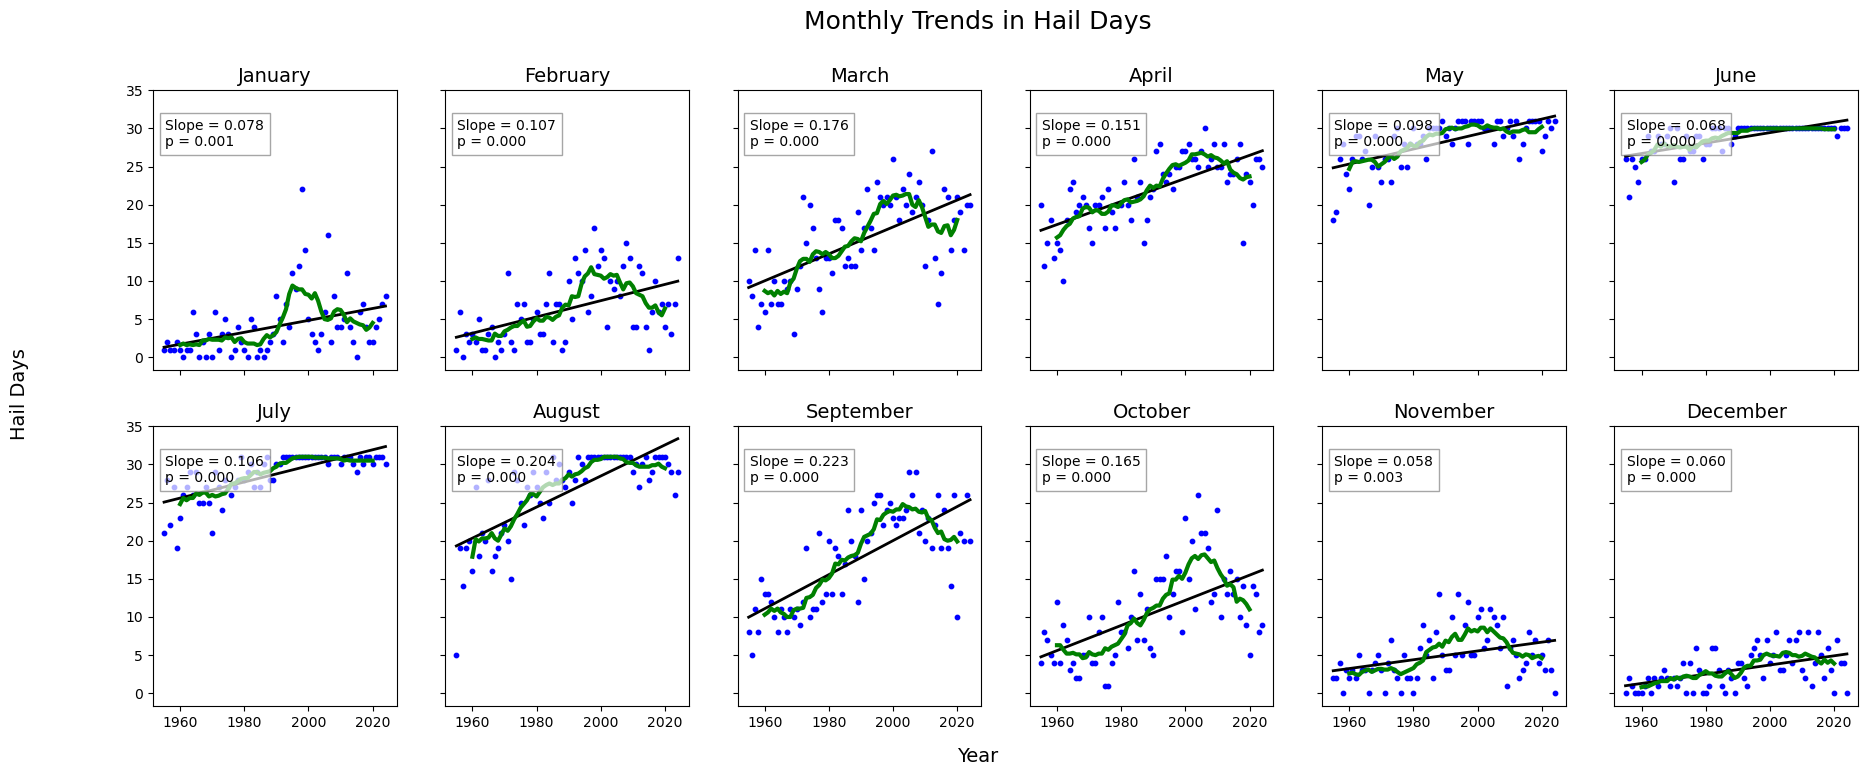

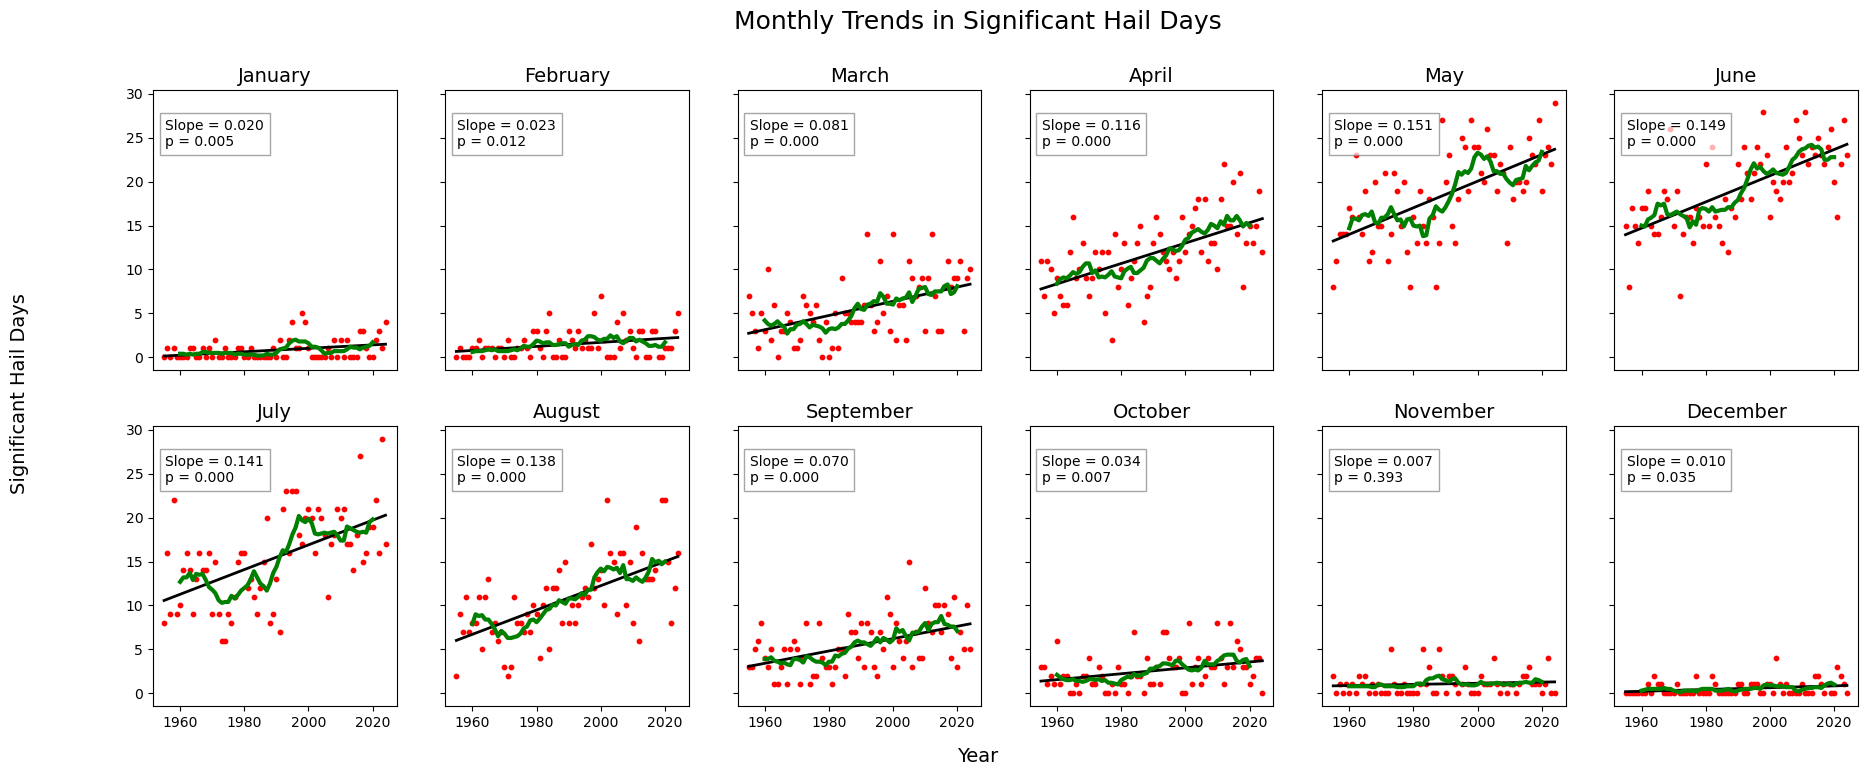

In [50]:
# Ensure 'month' and 'year' columns exist
df_hail['month'] = df_hail['date'].dt.month
df_hail['year'] = df_hail['date'].dt.year
df_sig['month'] = df_sig['date'].dt.month
df_sig['year'] = df_sig['date'].dt.year

# Define full year range
years = np.arange(1955, 2025)

def plot_monthly_panels(df, title_str, ylabel_str, color_str):
    fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(22, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for month in range(1, 13):
        ax = axes[month - 1]

        # Count unique dates for each year in this month
        monthly_counts = df[df['month'] == month].groupby('year')['date'].nunique().reindex(years, fill_value=0)

        x = years
        y = monthly_counts.values

        # Linear regression
        slope, intercept, r_val, p_val, _ = linregress(x, y)
        trend = slope * x + intercept

        # Compute 10-year rolling mean
        rolling = pd.Series(y, index=x).rolling(window=10, center=True).mean()

        # Plot raw data and trend line
        ax.scatter(x, y, color=color_str, s=10, label='Days')
        ax.plot(x, trend, color='black', linewidth=2, label='Trend')

        # Plot 5-year rolling mean (dashed)
        ax.plot(x, rolling, linestyle='-', color='green', linewidth=3, alpha=1, label='10-yr mean')

        # Annotate slope and p-value
        ax.text(0.05, 0.80,
                f'Slope = {slope:.3f}\np = {p_val:.3f}',
                transform=ax.transAxes,
                fontsize=10,
                bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7))

        # Month title
        ax.set_title(pd.to_datetime(str(month), format='%m').strftime('%B'), fontsize=14)

    # Shared labels and title
    fig.suptitle(title_str, fontsize=18)
    fig.text(0.5, 0.04, 'Year', ha='center', fontsize=14)
    fig.text(0.06, 0.5, ylabel_str, va='center', rotation='vertical', fontsize=14)

    plt.show()

# Plot hail days
plot_monthly_panels(df_hail, 'Monthly Trends in Hail Days', 'Hail Days', 'blue')

# Plot significant hail days
plot_monthly_panels(df_sig, 'Monthly Trends in Significant Hail Days', 'Significant Hail Days', 'red')

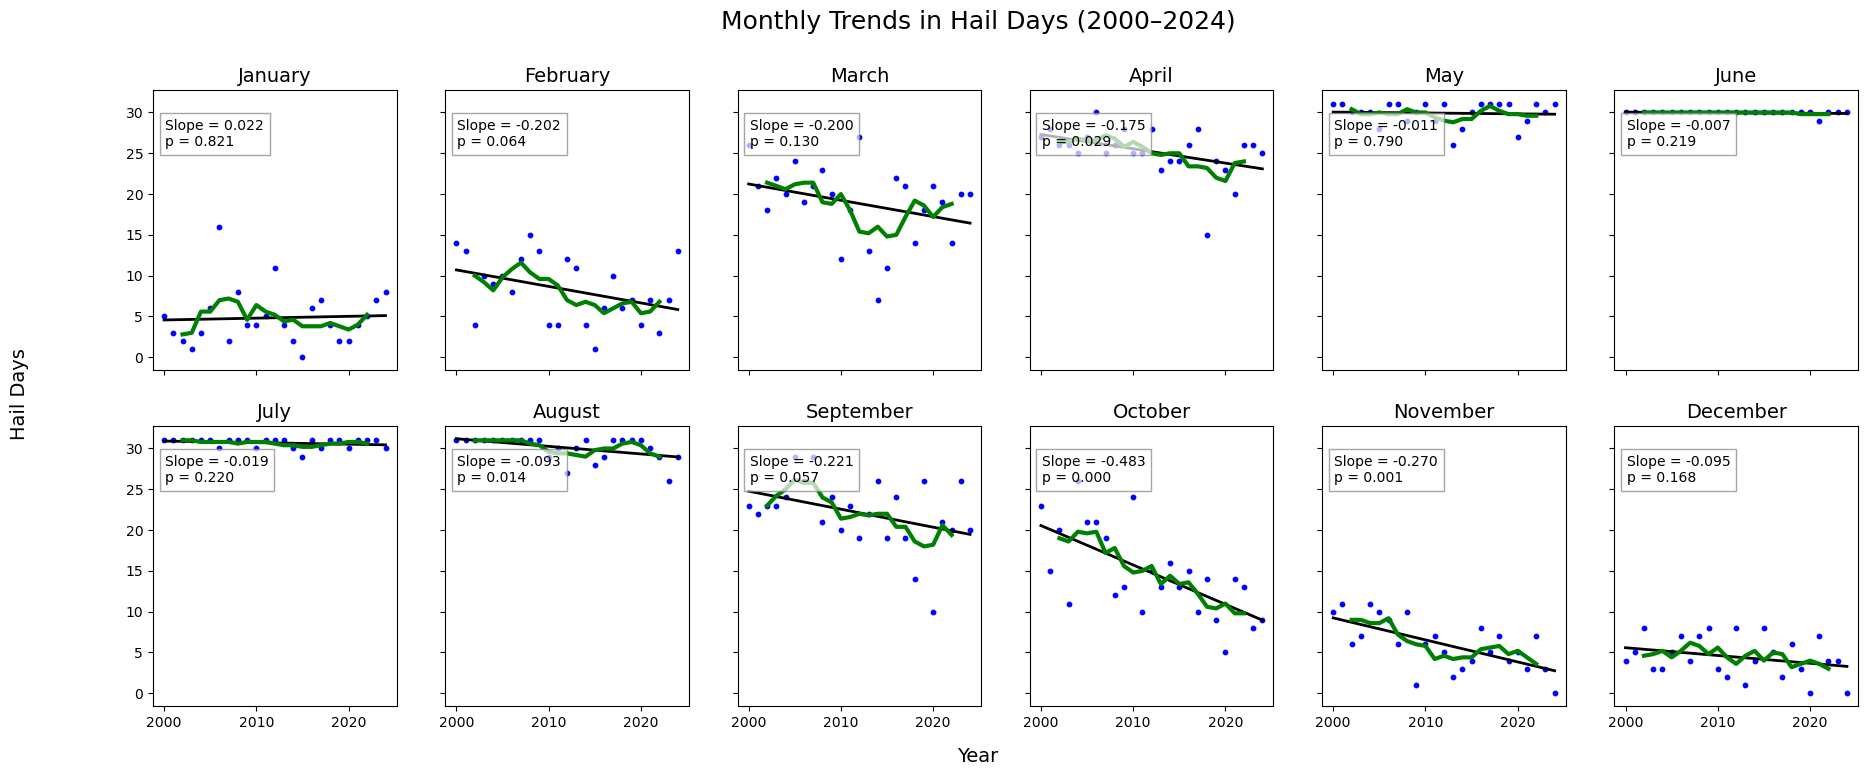

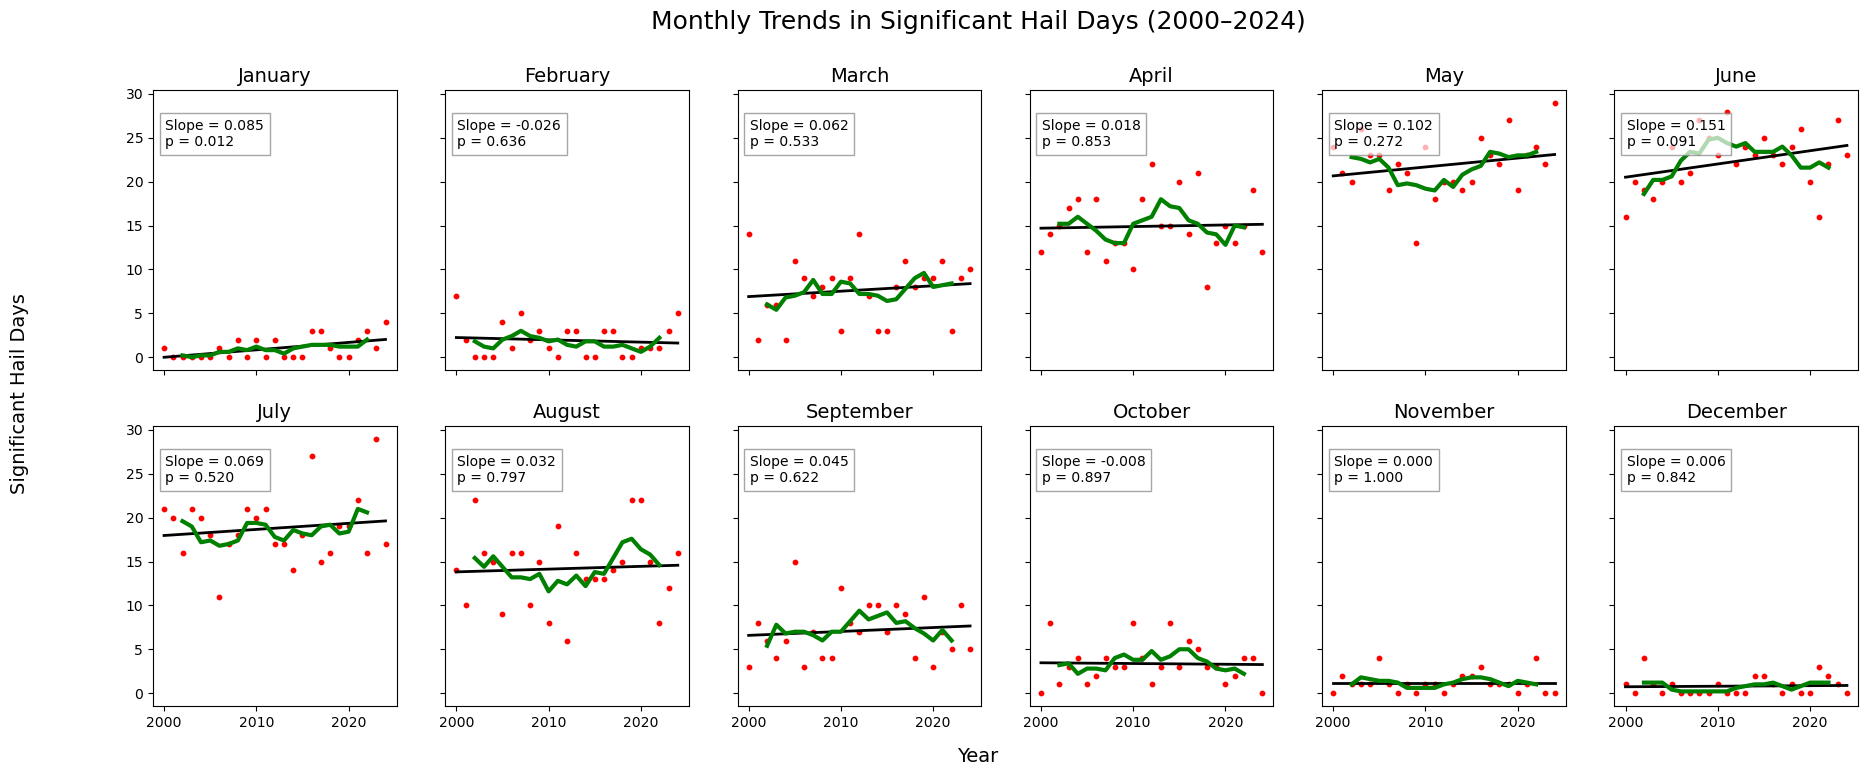

In [51]:
# Filter data to 2000–2024 only
df_hail_2000 = df_hail[(df_hail['year'] >= 2000) & (df_hail['year'] <= 2024)].copy()
df_sig_2000 = df_sig[(df_sig['year'] >= 2000) & (df_sig['year'] <= 2024)].copy()

# Define year range for 2000–2024
years_2000 = np.arange(2000, 2025)

def plot_monthly_panels(df, years, title_str, ylabel_str, color_str):
    fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(22, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for month in range(1, 13):
        ax = axes[month - 1]

        # Count unique hail days per year for the given month
        monthly_counts = (
            df[df['month'] == month]
            .groupby('year')['date']
            .nunique()
            .reindex(years, fill_value=0)
        )

        x = years
        y = monthly_counts.values

        # Linear regression
        slope, intercept, r_val, p_val, _ = linregress(x, y)
        trend = slope * x + intercept

        # Rolling 5-year mean
        rolling = pd.Series(y, index=x).rolling(window=5, center=True).mean()

        # Plot raw values and trends
        ax.scatter(x, y, color=color_str, s=10)
        ax.plot(x, trend, color='black', linewidth=2)
        ax.plot(x, rolling, linestyle='-', color='green', linewidth=3, label='5-yr mean')

        # Annotations
        ax.text(0.05, 0.80,
                f'Slope = {slope:.3f}\np = {p_val:.3f}',
                transform=ax.transAxes,
                fontsize=10,
                bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7))

        ax.set_title(pd.to_datetime(str(month), format='%m').strftime('%B'), fontsize=14)

    # Shared labels and title
    fig.suptitle(title_str, fontsize=18)
    fig.text(0.5, 0.04, 'Year', ha='center', fontsize=14)
    fig.text(0.06, 0.5, ylabel_str, va='center', rotation='vertical', fontsize=14)

  #  plt.tight_layout(rect=[0.05, 0.05, 1, 0.93])
    plt.show()

# Run plots
plot_monthly_panels(df_hail_2000, years_2000, 'Monthly Trends in Hail Days (2000–2024)', 'Hail Days', 'blue')
plot_monthly_panels(df_sig_2000, years_2000, 'Monthly Trends in Significant Hail Days (2000–2024)', 'Significant Hail Days', 'red')

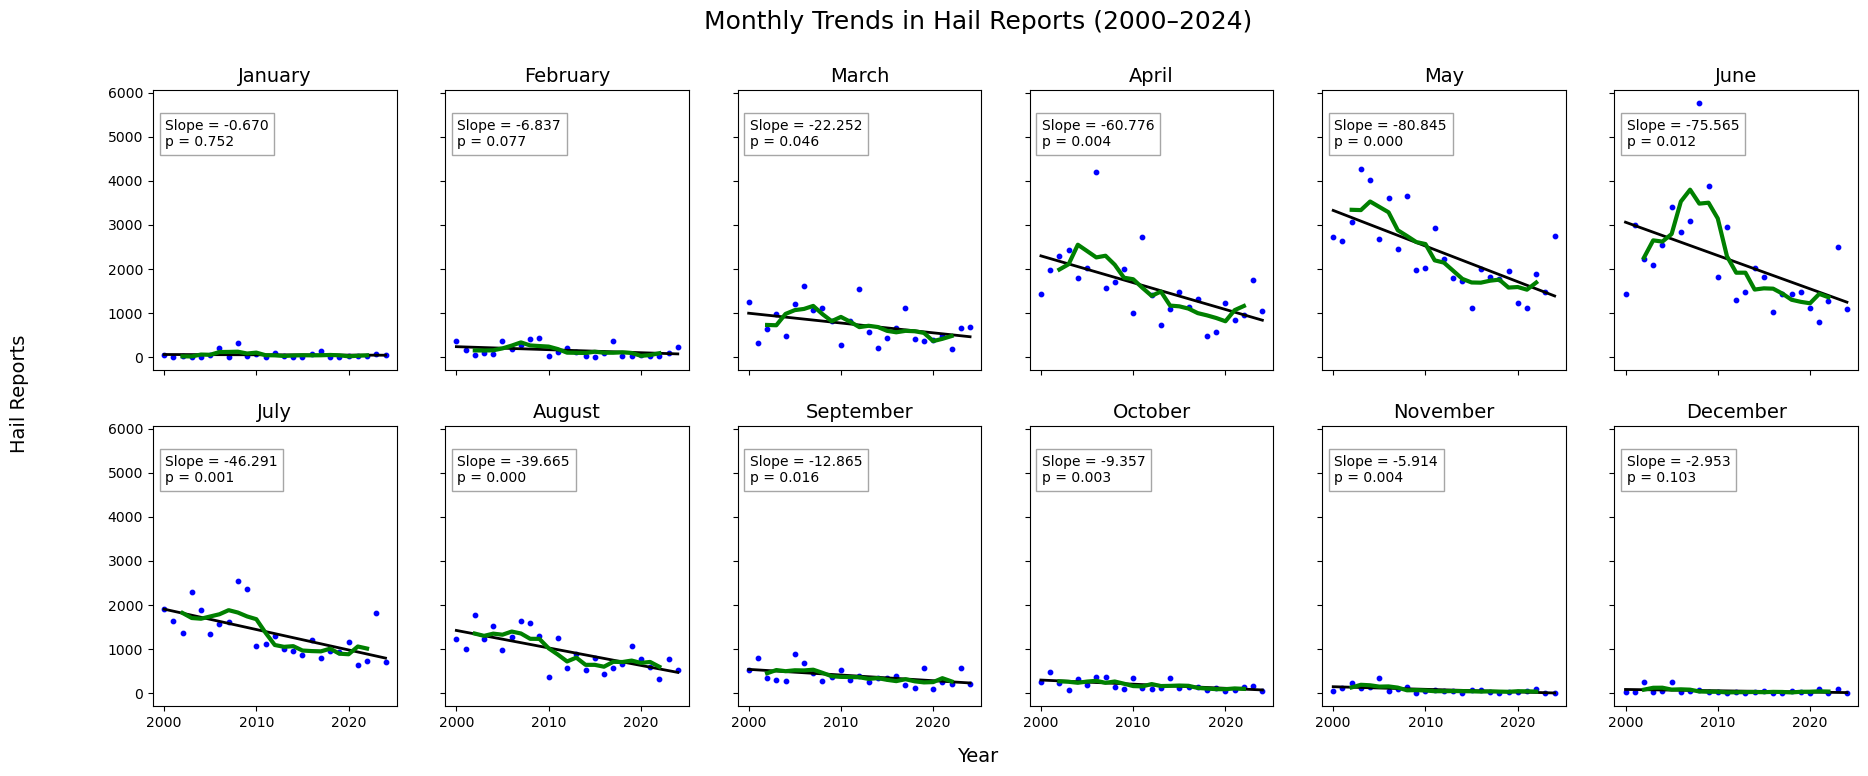

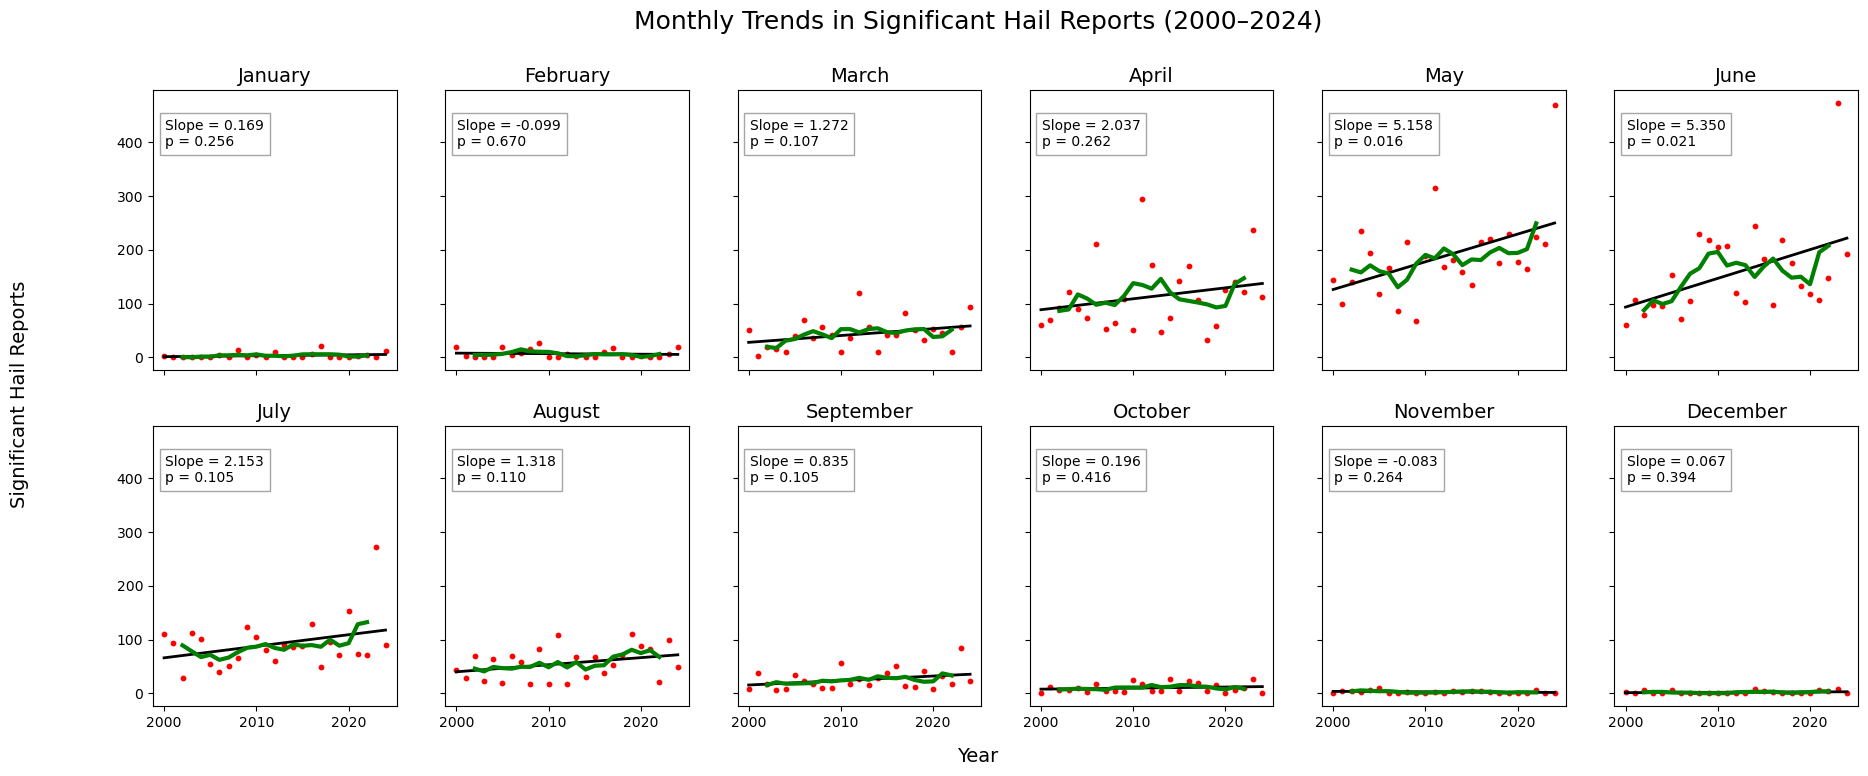

In [88]:
# Filter data to 2000–2024 only
df_hail_2000 = df_hail[(df_hail['year'] >= 2000) & (df_hail['year'] <= 2024)].copy()
df_sig_2000 = df_sig[(df_sig['year'] >= 2000) & (df_sig['year'] <= 2024)].copy()

# Define year range for 2000–2024
years_2000 = np.arange(2000, 2025)

def plot_monthly_panels(df, years, title_str, ylabel_str, color_str):
    fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(22, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for month in range(1, 13):
        ax = axes[month - 1]

        # Count hail reports per year for the given month
        monthly_counts = (
            df[df['mo'] == month]
            .groupby('year')
            .size()
            .reindex(years, fill_value=0)
        )

        x = years
        y = monthly_counts.values

        # Linear regression
        slope, intercept, r_val, p_val, _ = linregress(x, y)
        trend = slope * x + intercept

        # Rolling 5-year mean
        rolling = pd.Series(y, index=x).rolling(window=5, center=True).mean()

        # Plot
        ax.scatter(x, y, color=color_str, s=10)
        ax.plot(x, trend, color='black', linewidth=2)
        ax.plot(x, rolling, linestyle='-', color='green', linewidth=3)

        # Annotations
        ax.text(0.05, 0.80,
                f'Slope = {slope:.3f}\np = {p_val:.3f}',
                transform=ax.transAxes,
                fontsize=10,
                bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7))

        ax.set_title(pd.to_datetime(str(month), format='%m').strftime('%B'), fontsize=14)

    fig.suptitle(title_str, fontsize=18)
    fig.text(0.5, 0.04, 'Year', ha='center', fontsize=14)
    fig.text(0.06, 0.5, ylabel_str, va='center', rotation='vertical', fontsize=14)

    plt.show()

# Plot the panels
plot_monthly_panels(
    df_hail_2000, years_2000,
    'Monthly Trends in Hail Reports (2000–2024)',
    'Hail Reports',
    'blue'
)

plot_monthly_panels(
    df_sig_2000, years_2000,
    'Monthly Trends in Significant Hail Reports (2000–2024)',
    'Significant Hail Reports',
    'red'
)

In [52]:
# Define state groupings
regions = {
    'CONUS': None,  # special case: no filtering
    'Southern Great Plains': ['TX', 'NM', 'KS', 'OK', 'CO'],
    'Northern Great Plains': ['NE', 'SD', 'ND', 'MT', 'WY'],
    'Midwest': ['IA', 'MO', 'MN', 'WI', 'IL', 'IN', 'OH', 'MI'],
    'Southeast': ['LA', 'AR', 'MS', 'AL', 'GA', 'FL', 'TN', 'KY', 'SC', 'NC', 'VA']
}

# Function to generate counts by region
def get_counts_by_region(df, state_list=None):
    if state_list is not None:
        df_region = df[df['st'].isin(state_list)].copy()
    else:
        df_region = df.copy()  # CONUS = all data

    counts = df_region.groupby('year')['date'].nunique()
    return counts.reindex(years, fill_value=0)

# Create regional hail and significant hail counts
hail_counts_by_region = {}
sig_counts_by_region = {}

for region_name, state_list in regions.items():
    hail_counts_by_region[region_name] = get_counts_by_region(df_hail, state_list)
    sig_counts_by_region[region_name] = get_counts_by_region(df_sig, state_list)

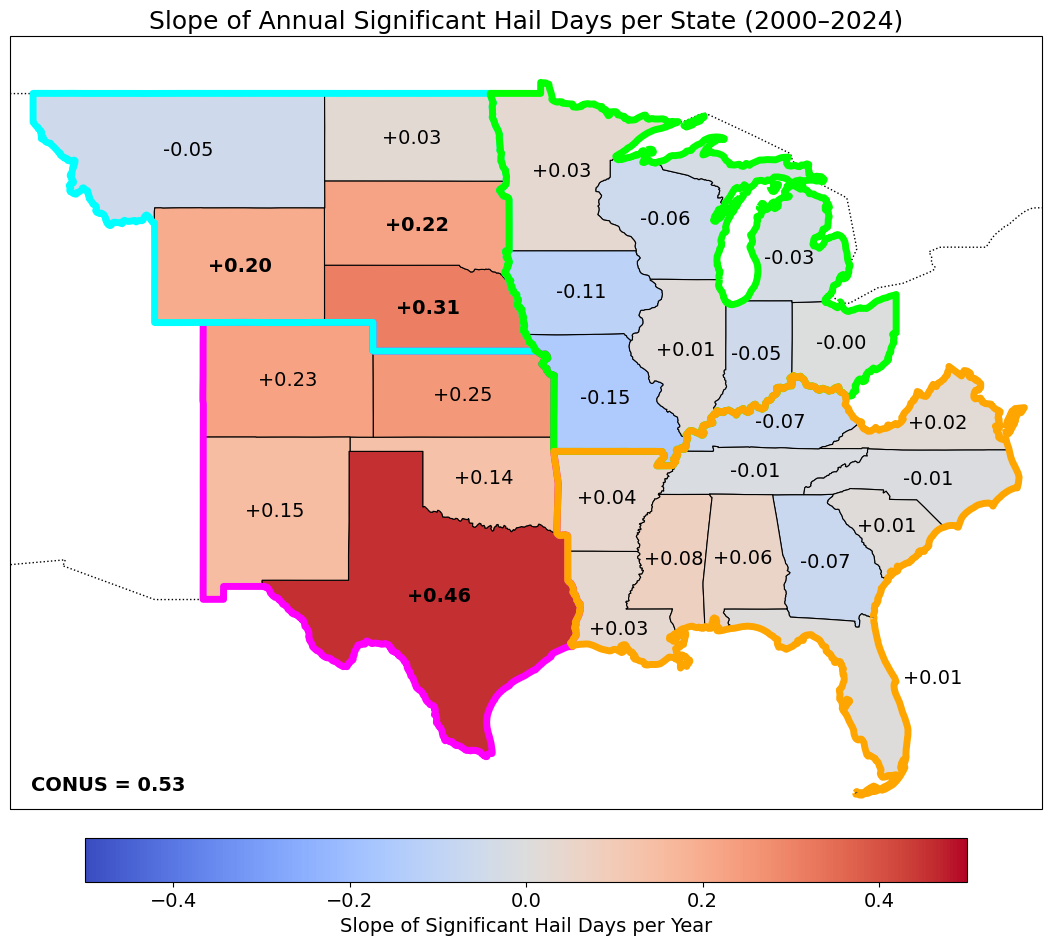

In [7]:
# Define the states to include
plot_states = ['AL', 'AR', 'CO', 'FL', 'GA', 'IA', 'IL', 'IN', 'KS', 'KY', 'LA',
               'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NM', 'OH', 'OK',
               'SC', 'SD', 'TN', 'TX', 'VA', 'WI', 'WY']
years = np.arange(2000, 2025)

regions = {
    "Region 1": ['TX', 'OK', 'KS', 'CO', 'NM'],
    "Region 2": ['NE', 'SD', 'ND', 'MT', 'WY'],
    "Region 3": ['MN', 'WI', 'IA', 'MO', 'IL', 'IN', 'OH', 'MI'],
    "Region 4": ['KY', 'TN', 'AR', 'LA', 'MS', 'AL', 'GA', 'FL', 'SC', 'NC', 'VA']
}

# Define manual text offsets for problematic states (lon_offset, lat_offset)
text_offsets = {
    'LA': (0, -0.7),    
    'MI': (0.5, -1.1),     
    'FL': (3.5, 0),     
}

# Compute slopes and p-values
state_results = []
for state in plot_states:
    df_state = df_sig[df_sig['st'] == state]
    counts = df_state.groupby('year')['date'].nunique().reindex(years, fill_value=0)
    slope, intercept, r_val, p_val, stderr = linregress(counts.index, counts.values)
    state_results.append({'state': state, 'slope': slope, 'pval': p_val})

# Convert to DataFrame for easier merging
df_slope = pd.DataFrame(state_results)

# Load U.S. states geometry
gdf_states = gpd.read_file('https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_20m.zip')
gdf_states = gdf_states[gdf_states['STUSPS'].isin(plot_states)]

# Merge slope data with geometry
gdf_states = gdf_states.merge(df_slope, left_on='STUSPS', right_on='state')

# Plotting
fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-117, -74.5, 24, 49])
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Create a color map that goes from blue for negative slopes to red for positive slopes
norm = TwoSlopeNorm(vmin=-0.5, vcenter=0, vmax=0.5)  # Set colorbar limits to -0.5 to 0.5
cmap = plt.cm.coolwarm  # This will go from blue to red

# Plot shaded states
gdf_states.plot(column='slope', cmap=cmap, linewidth=0.8, ax=ax,
                edgecolor='black', transform=ccrs.PlateCarree(), norm=norm)

# Annotate each state with slope and p-value
for idx, row in gdf_states.iterrows():
    state = row['state']
    lon, lat = row['geometry'].centroid.coords[0]
    slope = row['slope']
    pval = row['pval']

    # Get offset if exists
    offset = text_offsets.get(state, (0, 0))
    lon_offset = lon + offset[0]
    lat_offset = lat + offset[1]

    # Bold if significant
    fontweight = 'bold' if pval < 0.05 else 'normal'

    # Draw the text at adjusted position
    ax.text(lon_offset, lat_offset, f"{slope:+.2f}", ha='center', va='center',
            fontsize=14, fontweight=fontweight, color='black', transform=ccrs.PlateCarree())

# Add CONUS annotation
ax.text(0.02, 0.02, "CONUS = 0.53", transform=ax.transAxes,
        fontsize=14, fontweight='bold', color='black', ha='left', va='bottom')

# Title
plt.title("Slope of Annual Significant Hail Days per State (2000–2024)", fontsize=18)

region_colors = ['magenta', 'cyan', 'lime', 'orange']

for (region_name, state_list), color in zip(regions.items(), region_colors):
    region_gdf = gdf_states[gdf_states['STUSPS'].isin(state_list)]
    region_outline = region_gdf.dissolve()
    
    region_outline.boundary.plot(
        ax=ax,
        edgecolor=color,
        linewidth=5,
        transform=ccrs.PlateCarree()
    )

# Colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.03, shrink=0.6)
cbar.set_label("Slope of Significant Hail Days per Year", fontsize=14)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig("state_slope_map_colored_2000_2024_regions.png", dpi=300)
plt.show()

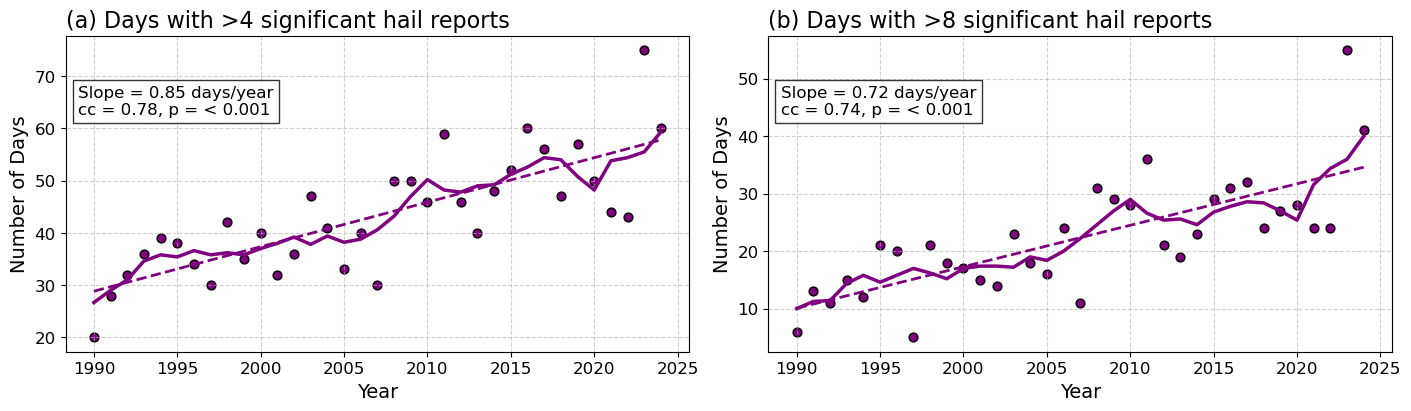

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Ensure 'date' is datetime 
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# Define significant hail reports 
df_sig = df[df['mag'] >= 2].copy()

# Count significant reports per day
reports_per_day = df_sig.groupby('date').size().reset_index(name='count')
reports_per_day['year'] = reports_per_day['date'].dt.year

# Filter to 1990–2024
reports_per_day = reports_per_day[
    (reports_per_day['year'] >= 1990) & (reports_per_day['year'] <= 2024)
]

# Thresholds for the two panels
thresholds = [4, 8]
titles = [
    "(a) Days with >4 significant hail reports",
    "(b) Days with >8 significant hail reports"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

years = np.arange(1990, 2025)

for ax, thresh, title in zip(axes, thresholds, titles):

    # Filter days exceeding threshold
    days = reports_per_day[reports_per_day['count'] > thresh]

    # Count per year
    counts = days.groupby('year')['date'].nunique()
    counts = counts.reindex(years, fill_value=0)

    # Running mean
    running_mean = counts.rolling(window=5, center=True, min_periods=1).mean()

    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(years, counts)
    trend = slope * years + intercept

    # Plotting
    ax.scatter(years, counts, color='purple', edgecolor='black', s=40)
    ax.plot(years, trend, color='purple', linestyle='--', linewidth=2)
    ax.plot(years, running_mean, color='purple', linewidth=2.5)

    ax.set_title(title, fontsize=16, loc='left')
    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel("Number of Days", fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(labelsize=12)

    # Regression stats box
    textstr = (
        f"Slope = {slope:.2f} days/year\n"
        f"cc = {r_value:.2f}, p = < 0.001"
    )
    ax.text(
        0.02, 0.75, textstr,
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
    )

plt.savefig('60&80percentiles.png')
plt.show()


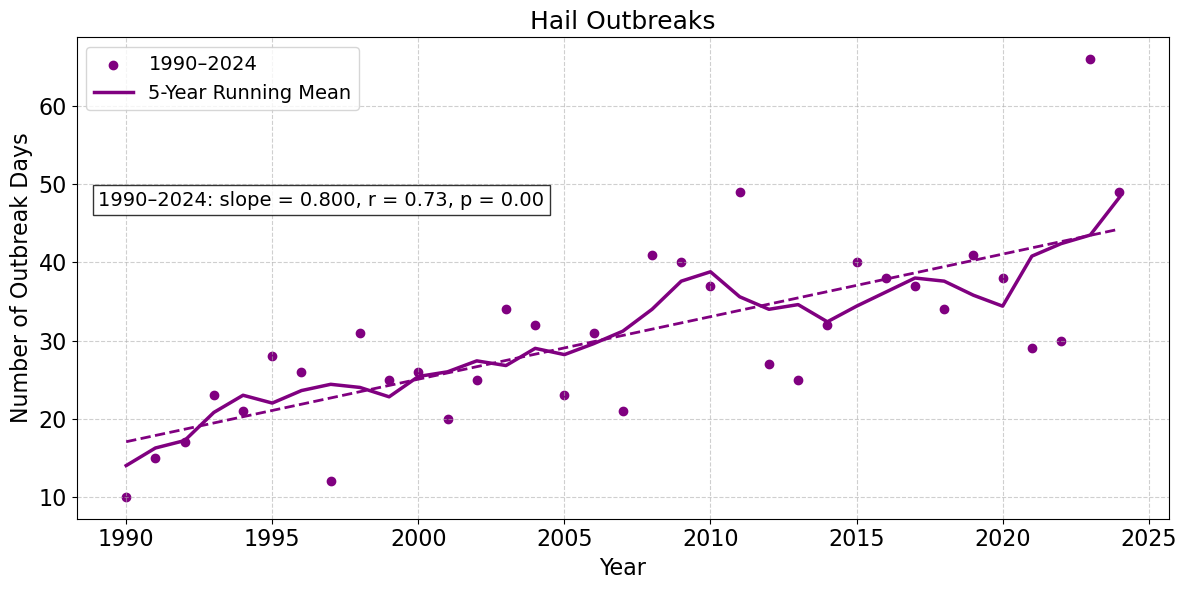

In [25]:
# Ensure 'date' is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# Define significant hail reports 
df_sig = df[df['mag'] >= 2].copy()

# Count significant reports per day
reports_per_day = df_sig.groupby('date').size().reset_index(name='count')

# Define outbreak days (> 6 sig hail reports)
outbreak_days = reports_per_day[reports_per_day['count'] > 6].copy()
outbreak_days['year'] = outbreak_days['date'].dt.year

# Filter to 1990–2024 
outbreak_days = outbreak_days[(outbreak_days['year'] >= 1990) & 
                              (outbreak_days['year'] <= 2024)]

# --- Count outbreak days per year 
outbreak_counts = outbreak_days.groupby('year')['date'].nunique()

# Reindex to ensure all years are present
years = np.arange(1990, 2025)
outbreak_counts = outbreak_counts.reindex(years, fill_value=0)

# Compute 5-year running mean (whole period)
running_mean = outbreak_counts.rolling(window=5, center=True, min_periods=1).mean()

# Split periods
#years_early = np.arange(1955, 1990)
years_late  = np.arange(1990, 2025)

#counts_early = outbreak_counts.loc[years_early]
counts_late  = outbreak_counts.loc[years_late]

# Separate linear regressions
#slope1, intercept1, r1, p1, _, = linregress(years_early, counts_early)
#trend1 = slope1 * years_early + intercept1

slope2, intercept2, r2, p2, _, = linregress(years_late, counts_late)
trend2 = slope2 * years_late + intercept2

# Plot
plt.figure(figsize=(12, 6))

# Early period (lighter)
#plt.scatter(years_early, counts_early, color='purple', alpha=0.35,
#            label='1955–1989')
#plt.plot(years_early, trend1, color='purple', linestyle='--', alpha=0.6)

# Late period (darker)
plt.scatter(years_late, counts_late, color='purple',
            label='1990–2024')
plt.plot(years_late, trend2, color='purple', linestyle='--', linewidth=2)

# Running mean (whole period)
plt.plot(years, running_mean, color='purple', linewidth=2.5,
         label='5-Year Running Mean')

# Vertical transition line
#plt.axvline(1989.5, color='black', linestyle='--', linewidth=1.5)

# Formatting
plt.title("Hail Outbreaks", fontsize=18)
plt.xlabel("Year", fontsize=16)
plt.ylabel("Number of Outbreak Days", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=14)
plt.tick_params(labelsize=16)

# Annotation (both regressions)
textstr = (
#    f"1955–1989: slope = {slope1:.3f}, r = {r1:.2f}, p = {p1:.2f}\n"
    f"1990–2024: slope = {slope2:.3f}, r = {r2:.2f}, p = {p2:.2f}"
)

plt.text(
    0.02, 0.65, textstr,
    transform=plt.gca().transAxes,
    fontsize=14,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

plt.tight_layout()
#plt.savefig('80_percentile_split_trends.png')
plt.show()


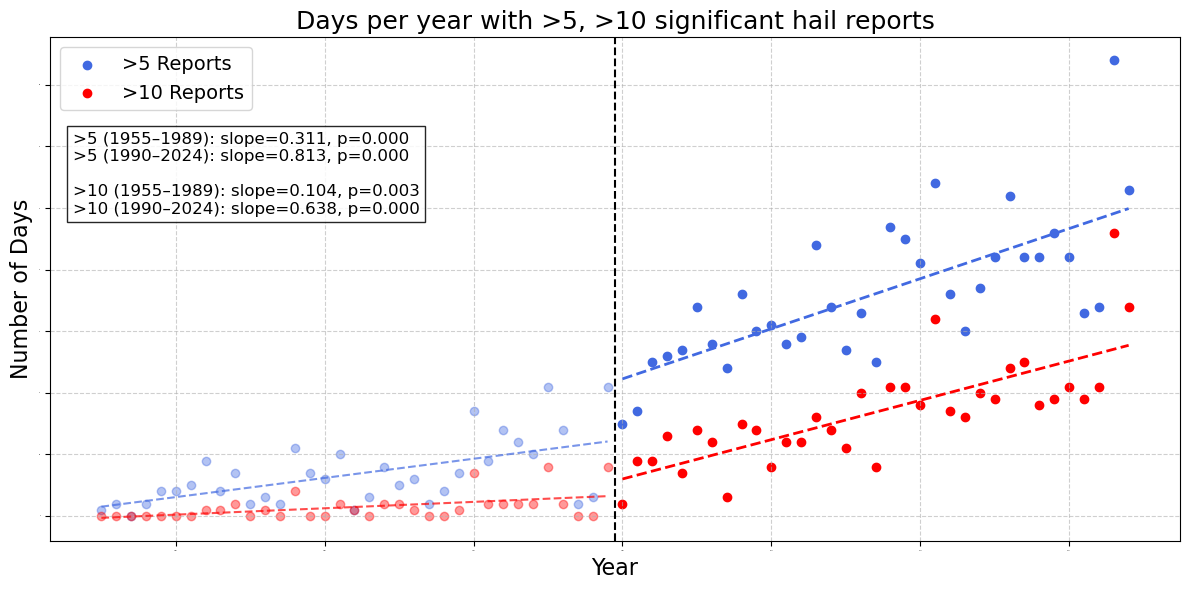

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# 1. Prepare daily significant hail counts
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

df_sig = df[df['mag'] >= 2].copy()

reports_per_day = df_sig.groupby('date').size().reset_index(name='count')
reports_per_day['year'] = reports_per_day['date'].dt.year

reports_per_day = reports_per_day[
    (reports_per_day['year'] >= 1955) &
    (reports_per_day['year'] <= 2024)
]

# 2. Define thresholds
gt5_days  = reports_per_day[reports_per_day['count'] > 5]
gt10_days = reports_per_day[reports_per_day['count'] > 10]

gt5_counts  = gt5_days.groupby('year')['date'].nunique()
gt10_counts = gt10_days.groupby('year')['date'].nunique()

years = np.arange(1955, 2025)

gt5_counts  = gt5_counts.reindex(years, fill_value=0)
gt10_counts = gt10_counts.reindex(years, fill_value=0)

# 3. Split early / late
years_early = np.arange(1955, 1990)
years_late  = np.arange(1990, 2025)

# >5 reports
gt5_early = gt5_counts.loc[years_early]
gt5_late  = gt5_counts.loc[years_late]

s5_e, i5_e, r5_e, p5_e, _ = linregress(years_early, gt5_early)
s5_l, i5_l, r5_l, p5_l, _ = linregress(years_late, gt5_late)

trend5_e = s5_e * years_early + i5_e
trend5_l = s5_l * years_late  + i5_l

# >10 reports 
gt10_early = gt10_counts.loc[years_early]
gt10_late  = gt10_counts.loc[years_late]

s10_e, i10_e, r10_e, p10_e, _ = linregress(years_early, gt10_early)
s10_l, i10_l, r10_l, p10_l, _ = linregress(years_late, gt10_late)

trend10_e = s10_e * years_early + i10_e
trend10_l = s10_l * years_late  + i10_l

# 4. Plot
plt.figure(figsize=(12, 6))

# >5 reports (blue)
plt.scatter(years_early, gt5_early, color='royalblue', alpha=0.4)
plt.scatter(years_late,  gt5_late,  color='royalblue', label='>5 Reports')

plt.plot(years_early, trend5_e, color='royalblue', linestyle='--', alpha=0.7)
plt.plot(years_late,  trend5_l,  color='royalblue', linestyle='--', linewidth=2)

# >10 reports (red)
plt.scatter(years_early, gt10_early, color='red', alpha=0.4)
plt.scatter(years_late,  gt10_late,  color='red', label='>10 Reports')

plt.plot(years_early, trend10_e, color='red', linestyle='--', alpha=0.7)
plt.plot(years_late,  trend10_l,  color='red', linestyle='--', linewidth=2)

# Vertical break
plt.axvline(1989.5, color='black', linestyle='--', linewidth=1.5)

# Labels
plt.title("Days per year with >5, >10 significant hail reports", fontsize=18)
plt.xlabel("Year", fontsize=16)
plt.ylabel("Number of Days", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=14)
plt.tick_params(labelsize=1)

# 5. Annotation
textstr = (
    f">5 (1955–1989): slope={s5_e:.3f}, p={p5_e:.3f}\n"
    f">5 (1990–2024): slope={s5_l:.3f}, p={p5_l:.3f}\n\n"
    f">10 (1955–1989): slope={s10_e:.3f}, p={p10_e:.3f}\n"
    f">10 (1990–2024): slope={s10_l:.3f}, p={p10_l:.3f}"
)

plt.text(
    0.02, 0.65, textstr,
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.85)
)

plt.tight_layout()
#plt.savefig('hail2_split.png')
plt.show()


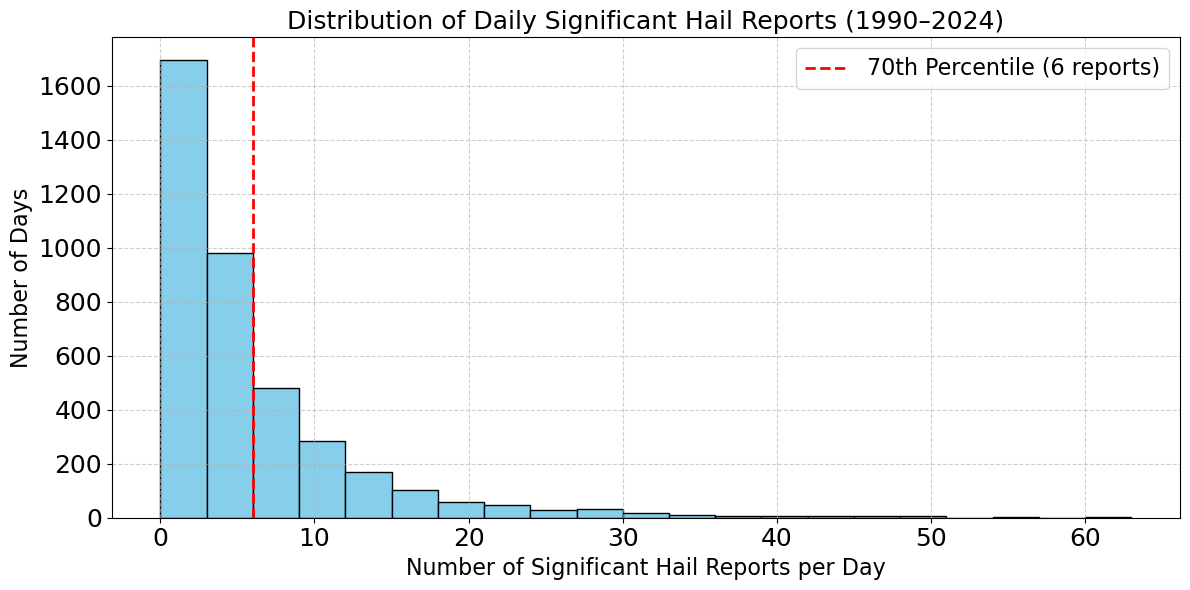

In [27]:
# Use the same significant hail daily counts
reports_per_day = df_sig.groupby('date').size().reset_index(name='count')

# Restrict to 1990–2024 for consistency
reports_per_day['year'] = reports_per_day['date'].dt.year
reports_per_day = reports_per_day[
    (reports_per_day['year'] >= 1990) &
    (reports_per_day['year'] <= 2024)
]

daily_counts = reports_per_day['count'].values

# Compute 80th percentile
p80 = np.percentile(daily_counts, 70)

# Define bins of width 3
max_count = daily_counts.max()
bins = np.arange(0, max_count + 3, 3)

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(daily_counts, bins=bins, color='skyblue', edgecolor='black')

# 80th percentile line
plt.axvline(
    p80,
    linestyle='--',
    linewidth=2,
    color='red',
    label=f'70th Percentile ({p80:.0f} reports)'
)

# Formatting
plt.xlabel('Number of Significant Hail Reports per Day', fontsize=16)
plt.ylabel('Number of Days', fontsize=16)
plt.title('Distribution of Daily Significant Hail Reports (1990–2024)', fontsize=18)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=16)
plt.tick_params(labelsize=18)

plt.tight_layout()
#plt.savefig('hail_reports_histogram_80th_percentile.png', dpi=300)
plt.show()


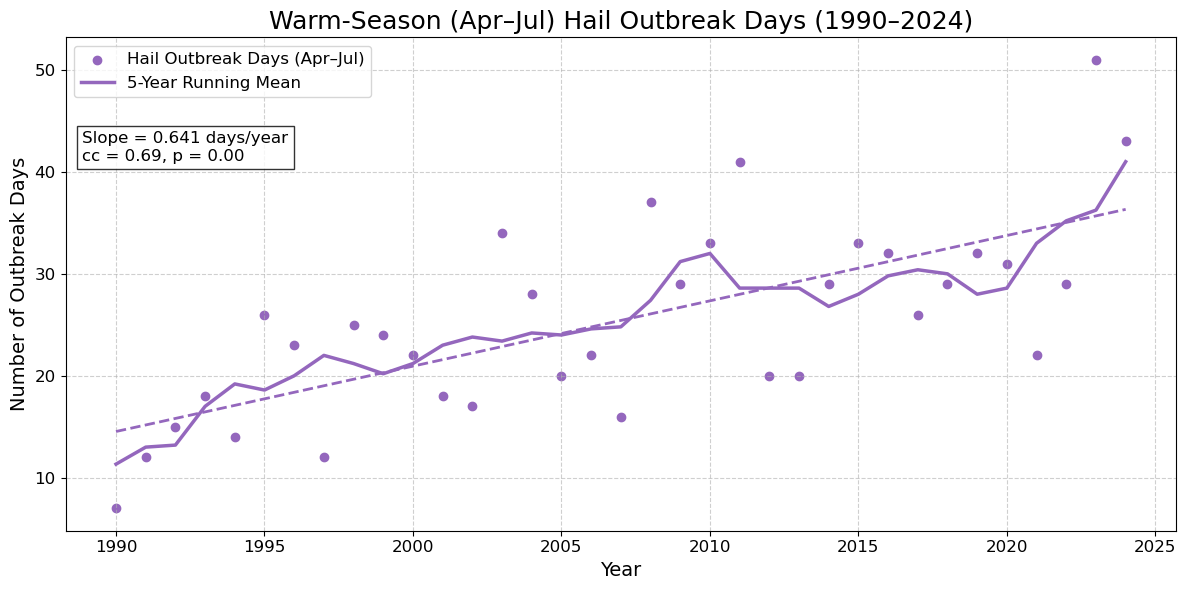

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Ensure 'date' is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# Keep only warm-season (April–July) reports
df = df[df['date'].dt.month.isin([4, 5, 6, 7])]

# Define significant hail reports
df_sig = df[df['mag'] >= 2].copy()

# Count significant reports per day 
reports_per_day = df_sig.groupby('date').size().reset_index(name='count')

# Define outbreak days (>= 6 sig hail reports)
outbreak_days = reports_per_day[reports_per_day['count'] > 6].copy()
outbreak_days['year'] = outbreak_days['date'].dt.year

# Filter to 1990–2024
outbreak_days = outbreak_days[(outbreak_days['year'] >= 1990) & (outbreak_days['year'] <= 2024)]

# Count outbreak days per year
outbreak_counts = outbreak_days.groupby('year')['date'].nunique()

# Reindex to ensure all years are present 
years = np.arange(1990, 2025)
outbreak_counts = outbreak_counts.reindex(years, fill_value=0)

# Compute 5-year running mean (centered)
running_mean = outbreak_counts.rolling(window=5, center=True, min_periods=1).mean()

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(years, outbreak_counts)
trend = slope * years + intercept

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(years, outbreak_counts, color='tab:purple', label='Hail Outbreak Days (Apr–Jul)')
plt.plot(years, trend, color='tab:purple', linestyle='--', linewidth=2)
plt.plot(years, running_mean, color='tab:purple', linewidth=2.5, label='5-Year Running Mean')

# Formatting
plt.title("Warm-Season (Apr–Jul) Hail Outbreak Days (1990–2024)", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Outbreak Days", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tick_params(labelsize=12)

# Annotation with regression stats 
textstr = (
    f"Slope = {slope:.3f} days/year\n"
    f"cc = {r_value:.2f}, p = {p_value:.2f}"
)
plt.text(
    0.015, 0.75, textstr,
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

plt.tight_layout()
plt.show()


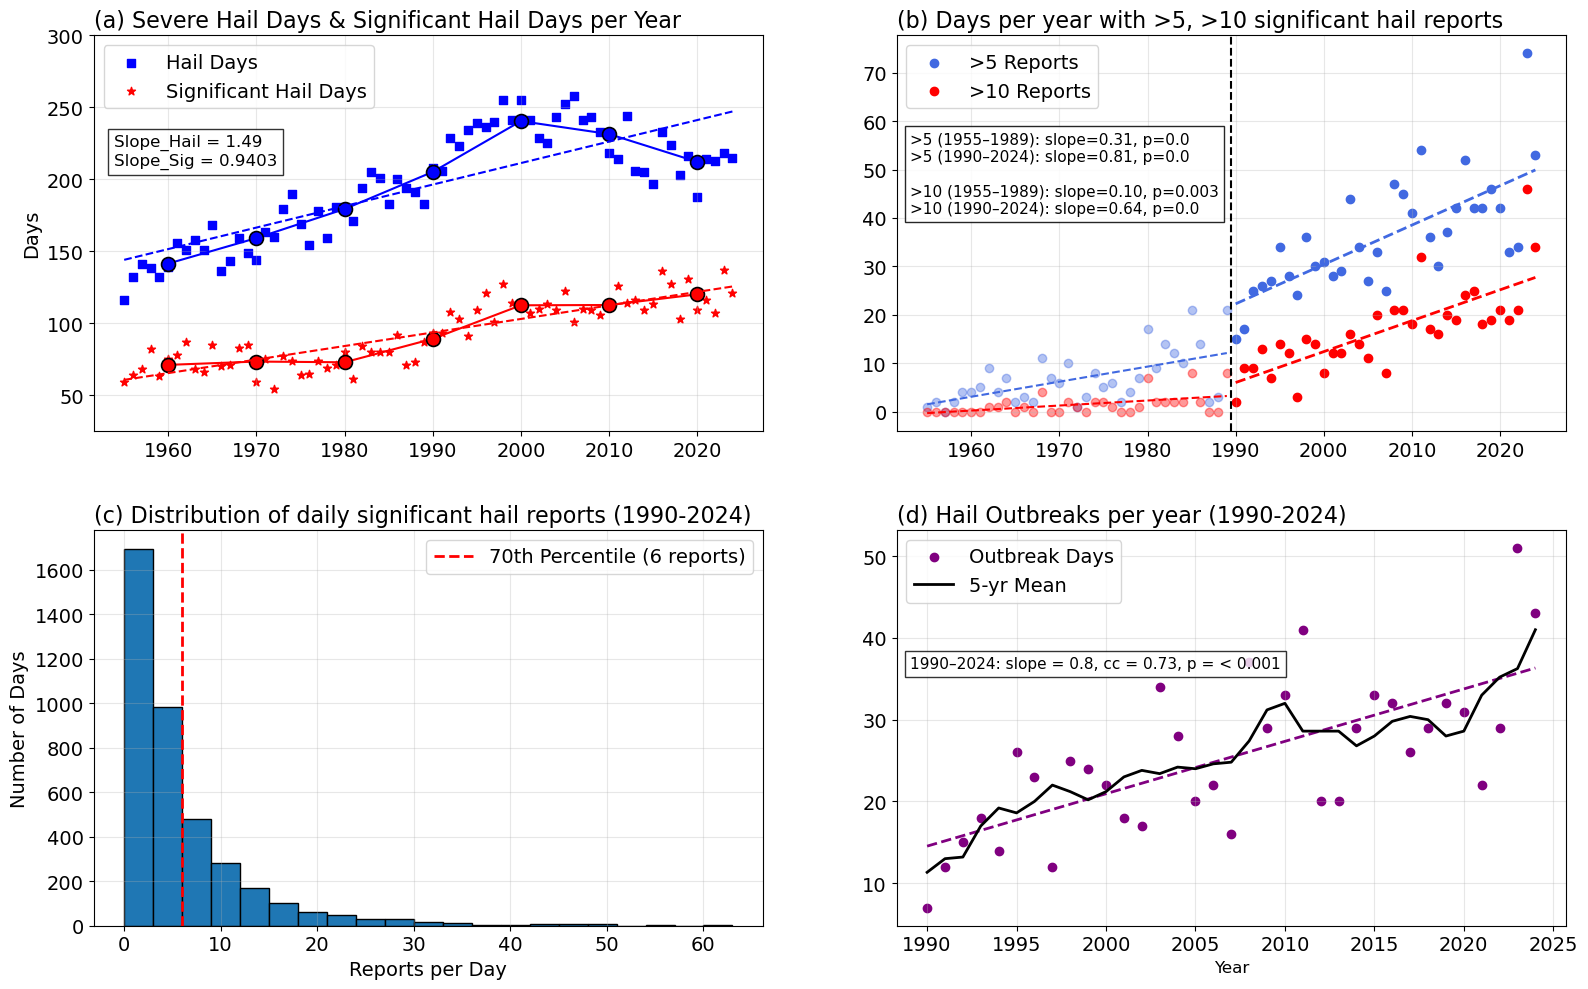

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
(ax1, ax2), (ax3, ax4) = axes

# Panel (a)
years = np.arange(1955, 2025)
yearss = [1960,1970,1980,1990,2000,2010,2020]

ax1.scatter(years, hail_counts, color='blue', marker='s', label='Hail Days')
ax1.scatter(years, sig_counts, color='red', marker='*', label='Significant Hail Days')

ax1.plot(yearss, hail_decades, color='blue', marker='o', markersize=10, markeredgecolor='black', markeredgewidth=1.2)
ax1.plot(yearss, sig_decades, color='red', marker='o', markersize=10, markeredgecolor='black', markeredgewidth=1.2)

#ax1.axvline(1989.5, color='black', linestyle='--')

# Trends
slope_hail, intercept_hail, r_hail, p_hail, _ = linregress(years, hail_counts)
slope_sig, intercept_sig, r_sig, p_sig, _ = linregress(years, sig_counts)

trend_hail = slope_hail * years + intercept_hail
trend_sig  = slope_sig  * years + intercept_sig

textstr = '\n'.join((
    f"Slope_Hail = {slope_hail:.2f}",
    f"Slope_Sig = {slope_sig:.4f}"
))

ax1.text(0.03, 0.75, textstr,
         transform=ax1.transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))

ax1.plot(years, trend_hail, color='blue', linestyle='--')
ax1.plot(years, trend_sig,  color='red', linestyle='--')

ax1.set_title(f"(a) Severe Hail Days & Significant Hail Days per Year", fontsize=16, loc='left')
ax1.set_ylabel("Days", fontsize=14)
ax1.set_ylim(25,300)
ax1.legend(fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.tick_params(labelsize=14)

# Panel (b)
ax2.scatter(years_early, gt5_early, color='royalblue', alpha=0.4)
ax2.scatter(years_late,  gt5_late,  color='royalblue', label='>5 Reports')

ax2.plot(years_early, trend5_e, color='royalblue', linestyle='--')
ax2.plot(years_late,  trend5_l, color='royalblue', linestyle='--', linewidth=2)

ax2.scatter(years_early, gt10_early, color='red', alpha=0.4)
ax2.scatter(years_late,  gt10_late,  color='red', label='>10 Reports')

ax2.plot(years_early, trend10_e, color='red', linestyle='--')
ax2.plot(years_late,  trend10_l, color='red', linestyle='--', linewidth=2)

ax2.axvline(1989.5, color='black', linestyle='--')

textstr = (
    f">5 (1955–1989): slope={s5_e:.2f}, p={p5_e:.1f}\n"
    f">5 (1990–2024): slope={s5_l:.2f}, p={p5_l:.1f}\n\n"
    f">10 (1955–1989): slope={s10_e:.2f}, p={p10_e:.3f}\n"
    f">10 (1990–2024): slope={s10_l:.2f}, p={p10_l:.1f}"
)

plt.text(
    0.02, 0.55, textstr,
    transform=ax2.transAxes,
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.85)
)

ax2.set_title(f"(b) Days per year with >5, >10 significant hail reports", fontsize=16, loc='left')
ax2.grid(True, alpha=0.3)
ax2.tick_params(labelsize=14)
ax2.legend(fontsize=14)

# Panel (c)
ax3.hist(daily_counts, bins=bins, edgecolor='black')

ax3.axvline(p80, linestyle='--', linewidth=2, color='red',
            label=f'70th Percentile ({p80:.0f} reports)')

ax3.set_title("(c) Distribution of daily significant hail reports (1990-2024)", fontsize=16, loc='left')
ax3.set_xlabel("Reports per Day", fontsize=14)
ax3.set_ylabel("Number of Days", fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=14)
ax3.tick_params(labelsize=14)

# Panel (d)
#ax4.scatter(years_early, counts_early, color='purple', alpha=0.4)
ax4.scatter(years_late,  outbreak_counts,  color='purple', label='Outbreak Days')

#ax4.plot(years_early, trend1, color='purple', linestyle='--')
ax4.plot(years_late,  trend, color='purple', linestyle='--', linewidth=2)

ax4.plot(years_late, running_mean, color='black', linewidth=2, label='5-yr Mean')

#ax4.axvline(1989.5, color='black', linestyle='--')

ax4.set_title("(d) Hail Outbreaks per year (1990-2024)", fontsize=16, loc='left')
ax4.set_xlabel("Year", fontsize=12)

# Annotation (both regressions)
textstr = (
    f"1990–2024: slope = 0.8, cc = 0.73, p = < 0.001"
)

plt.text(
    0.02, 0.65, textstr,
    transform=ax4.transAxes,
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

ax4.grid(True, alpha=0.3)
ax4.tick_params(labelsize=14)
ax4.legend(fontsize=14)

# ==========================================================
# Final layout
# ==========================================================
plt.tight_layout()
plt.subplots_adjust(hspace=0.25, wspace=0.2)

plt.savefig("4panel_hail_figure_04212026.png", dpi=300)
plt.show()

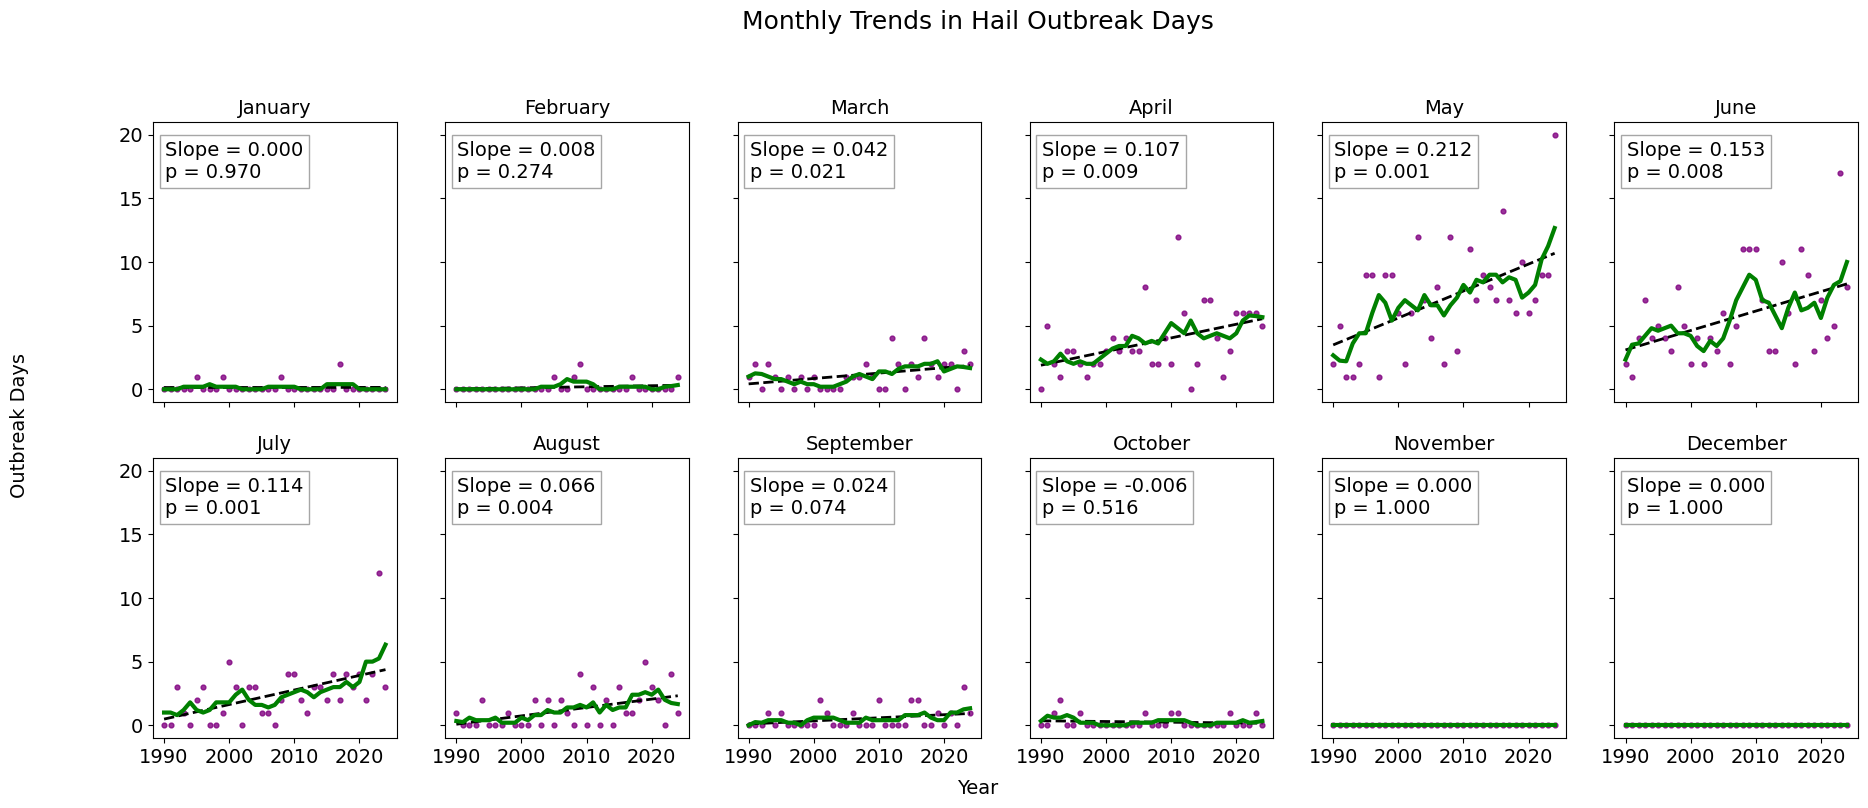

<Figure size 640x480 with 0 Axes>

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Ensure datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# Filter for significant hail (≥ 2.0 inch)
df_sig = df[df['mag'] >= 2].copy()

# Count number of sig hail reports per day
reports_per_day = df_sig.groupby('date').size().reset_index(name='count')

# Define hail outbreak days (>= 6 sig hail reports) 
outbreak_days = reports_per_day[reports_per_day['count'] > 8].copy()
outbreak_days['year'] = outbreak_days['date'].dt.year
outbreak_days['month'] = outbreak_days['date'].dt.month

# Restrict to 1990–2024
outbreak_days = outbreak_days[(outbreak_days['year'] >= 1990) & (outbreak_days['year'] <= 2024)]

# Define full range of years
years = np.arange(1990, 2025)

# Function to plot monthly panels
def plot_monthly_panels(df, title_str, ylabel_str, color_str):
    fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(22, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for month in range(1, 13):
        ax = axes[month - 1]

        # Count outbreak days per year for this month
        monthly_counts = (
            df[df['month'] == month]
            .groupby('year')['date']
            .nunique()
            .reindex(years, fill_value=0)
        )

        x = years
        y = monthly_counts.values

        # Linear regression
        slope, intercept, r_val, p_val, _ = linregress(x, y)
        trend = slope * x + intercept

        # 5-year running mean
        running = pd.Series(y, index=x).rolling(window=5, center=True, min_periods=1).mean()

        # Plot raw data, trend, and running mean
        ax.scatter(x, y, color=color_str, s=12, label='Outbreak Days', alpha=0.8)
        ax.plot(x, trend, color='black', linestyle='--', linewidth=2, label='Trend')
        ax.plot(x, running, color='green', linewidth=3, label='5-Year Mean')

        # Annotation for slope and p-value
        ax.text(
            0.05, 0.80,
            f"Slope = {slope:.3f}\np = {p_val:.3f}",
            transform=ax.transAxes,
            fontsize=14,
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7)
        )
        ax.tick_params(labelsize=14)
        # --- Month title ---
        ax.set_title(pd.to_datetime(str(month), format='%m').strftime('%B'), fontsize=14)

    # Shared labels & layout
    fig.suptitle(title_str, fontsize=18, y=1.02)
    fig.text(0.5, 0.04, 'Year', ha='center', fontsize=14)
    fig.text(0.06, 0.5, ylabel_str, va='center', rotation='vertical', fontsize=14)

    plt.show()
    plt.savefig("Figure2_hail_04202026.png", dpi=300)
# Plot monthly hail outbreak trends
plot_monthly_panels(outbreak_days, 'Monthly Trends in Hail Outbreak Days', 'Outbreak Days', 'purple')


In [68]:
def circular_running_mean(data, window=61):
    pad = window // 2  # 15 for 61-day window
    
    # Wrap data on both ends
    extended = np.concatenate([data[-pad:], data, data[:pad]])
    
    # Running mean
    kernel = np.ones(window) / window
    smoothed = np.convolve(extended, kernel, mode='valid')
    
    return smoothed

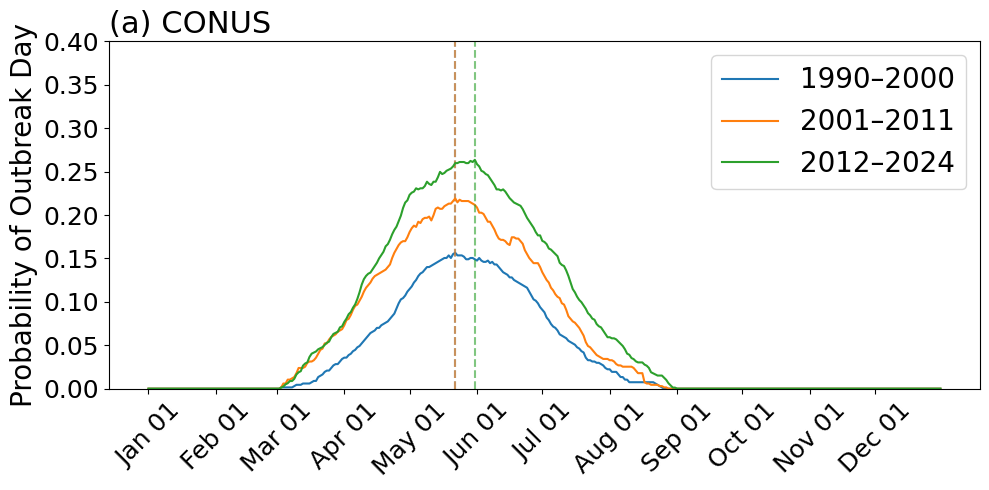

In [69]:
# Set up the figure
use_sig = True  # always True for hail outbreaks (≥2" reports)
periods = [(1990, 2000), (2001, 2011), (2012, 2024)]  # time periods
poly_deg = 10  # polynomial degree for smoothing
warm_months = [4, 5, 6, 7]  # warm season

# LOAD & FILTER DATA
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# Apply hail thresholds
df_hail_pre2010 = df[(df['date'] < '2010-01-01') & (df['mag'] >= 0.75)]
df_hail_post2010 = df[(df['date'] >= '2010-01-01') & (df['mag'] >= 1.0)]
df_hail = pd.concat([df_hail_pre2010, df_hail_post2010])
df_sig = df[df['mag'] >= 2.0].copy()

# Identify hail outbreak days (≥6 significant hail reports per day)
hail_daily_counts = df_sig.groupby('date').size().reset_index(name='count')
hail_outbreak_days = hail_daily_counts[hail_daily_counts['count'] > 8]['date']

# Restrict to warm-season outbreak days
df_hail_outbreaks = df_sig[df_sig['date'].isin(hail_outbreak_days)].copy()
df_hail_outbreaks = df_hail_outbreaks[df_hail_outbreaks['date'].dt.month.isin(warm_months)]

df_hail_outbreaks['year'] = df_hail_outbreaks['date'].dt.year
df_hail_outbreaks['doy'] = df_hail_outbreaks['date'].dt.dayofyear

# Remove Feb 29
df_hail_outbreaks = df_hail_outbreaks[
    ~((df_hail_outbreaks['date'].dt.month == 2) & (df_hail_outbreaks['date'].dt.day == 29))
]

# Function to compute seasonal probabilities
def compute_seasonality(df, start_year, end_year):
    """Compute probability of hail outbreak day by day-of-year for a given period."""
    period_df = df[(df['year'] >= start_year) & (df['year'] <= end_year)]
    total_years = end_year - start_year + 1
    
    # Count unique outbreak days per DOY
    outbreak_days_per_doy = (
        period_df.groupby(['year', 'doy']).size().reset_index().groupby('doy').size()
    )
    
    all_doys = np.arange(1, 366)
    probs = outbreak_days_per_doy.reindex(all_doys, fill_value=0) / total_years
    return all_doys, probs

# Plot
plt.figure(figsize=(10, 5))

for start, end in periods:
    doys, probs = compute_seasonality(df_hail_outbreaks, start, end)

    # 31-day circular running mean
    smoothed = circular_running_mean(probs.values, window=61)

    # Plot
    line, = plt.plot(doys, smoothed, label=f"{start}–{end}")
    color = line.get_color()

    # Peak detection (same as before)
    max_val = np.max(smoothed)
    peak_doys = doys[np.isclose(smoothed, max_val, atol=1e-4)]
    peak_doy = int(np.mean(peak_doys))
    
    plt.axvline(peak_doy, linestyle='--', alpha=0.6, color=color)

# Convert DOY to month/day ticks
xtick_days = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]  # roughly Apr–Aug
xtick_labels = [
    (datetime.date(2001, 1, 1) + datetime.timedelta(days=d - 1)).strftime('%b %d')
    for d in xtick_days
]

plt.xticks(xtick_days, labels=xtick_labels, fontsize=18, rotation=45)
plt.yticks(fontsize=18)
plt.title("(a) CONUS", fontsize=22, loc='left')
#plt.xlabel("Date", fontsize=15)
plt.ylabel("Probability of Outbreak Day", fontsize=20)
plt.ylim(0, 0.4)
plt.legend(fontsize=20)
plt.grid(False)
plt.tight_layout()
#plt.savefig('Seasonality_HailOutbreakDays_WarmSeason.png', dpi=300)
plt.show()


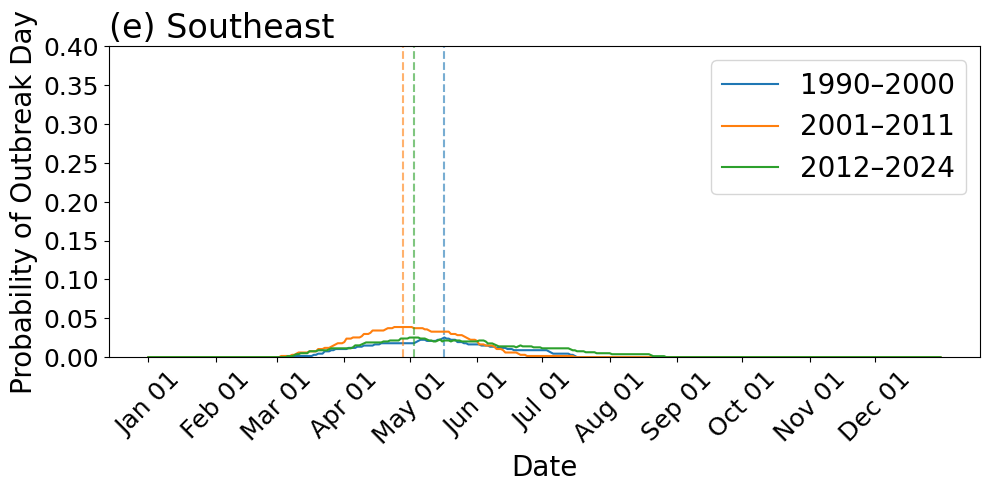

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Configuration
use_sig = True  # always True for hail outbreaks (≥2" reports)
selected_states = ['LA', 'AR', 'MS', 'AL', 'GA', 'FL', 'TN', 'KY', 'SC', 'NC', 'VA']
periods = [(1990, 2000), (2001, 2011), (2012, 2024)]  # time periods
poly_deg = 10  # polynomial degree for smoothing
warm_months = [4, 5, 6, 7]  # warm season

# Load and filter data
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# Apply hail thresholds
df_hail_pre2010 = df[(df['date'] < '2010-01-01') & (df['mag'] >= 0.75)]
df_hail_post2010 = df[(df['date'] >= '2010-01-01') & (df['mag'] >= 1.0)]
df_hail = pd.concat([df_hail_pre2010, df_hail_post2010])
df_sig = df[df['mag'] >= 2.0].copy()

# Filter to selected regions
df_sig = df_sig[df_sig['st'].isin(selected_states)]

# Identify hail outbreak days (≥6 significant hail reports per day)
hail_daily_counts = df_sig.groupby('date').size().reset_index(name='count')
hail_outbreak_days = hail_daily_counts[hail_daily_counts['count'] > 6]['date']

# Restrict to warm-season outbreak days
df_hail_outbreaks = df_sig[df_sig['date'].isin(hail_outbreak_days)].copy()
df_hail_outbreaks = df_hail_outbreaks[df_hail_outbreaks['date'].dt.month.isin(warm_months)]

df_hail_outbreaks['year'] = df_hail_outbreaks['date'].dt.year
df_hail_outbreaks['doy'] = df_hail_outbreaks['date'].dt.dayofyear

# Remove Feb 29
df_hail_outbreaks = df_hail_outbreaks[
    ~((df_hail_outbreaks['date'].dt.month == 2) & (df_hail_outbreaks['date'].dt.day == 29))
]

# === FUNCTION TO COMPUTE SEASONALITY PROBABILITIES ===
def compute_seasonality(df, start_year, end_year):
    """Compute probability of hail outbreak day by day-of-year for a given period."""
    period_df = df[(df['year'] >= start_year) & (df['year'] <= end_year)]
    total_years = end_year - start_year + 1
    
    # Count unique outbreak days per DOY
    outbreak_days_per_doy = (
        period_df.groupby(['year', 'doy']).size().reset_index().groupby('doy').size()
    )
    
    all_doys = np.arange(1, 366)
    probs = outbreak_days_per_doy.reindex(all_doys, fill_value=0) / total_years
    return all_doys, probs

# === PLOTTING ===
plt.figure(figsize=(10, 5))

for start, end in periods:
    doys, probs = compute_seasonality(df_hail_outbreaks, start, end)

    # --- 61-day circular running mean ---
    smoothed = circular_running_mean(probs.values, window=61)

    # Plot smoothed curve
    line, = plt.plot(doys, smoothed, label=f"{start}–{end}")
    color = line.get_color()

    # Find and mark peak DOY
    max_val = np.max(smoothed)
    peak_doys = doys[np.isclose(smoothed, max_val, atol=1e-4)]
    peak_doy = int(np.mean(peak_doys))
    
    plt.axvline(peak_doy, linestyle='--', alpha=0.6, color=color)

# Convert DOY to month/day ticks
xtick_days = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]  # roughly Apr–Aug
xtick_labels = [
    (datetime.date(2001, 1, 1) + datetime.timedelta(days=d - 1)).strftime('%b %d')
    for d in xtick_days
]

plt.xticks(xtick_days, labels=xtick_labels, fontsize=18, rotation=45)
plt.yticks(fontsize=18)
plt.title("(e) Southeast", fontsize=24, loc='left')
plt.xlabel("Date", fontsize=20)
plt.ylabel("Probability of Outbreak Day", fontsize=20)
plt.ylim(0, 0.4)
plt.legend(fontsize=20)
plt.grid(False)
plt.tight_layout()
plt.savefig('Seasonality_HailOutbreakDays_SE_WarmSeason.png', dpi=300)
plt.show()
